In [47]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 11.1 MB/s  0:00:00m0:00:01

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [83]:
%pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [lightgbm]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from transfermarkt_utils import run_random_forest
from transfermarkt_utils import run_linear_regression
from transfermarkt_utils import run_light_gbm
from transfermarkt_utils import run_xgboost

In [2]:
final_model_data = pd.read_csv(
    "/Users/kachi/Documents/Thesis/data/processed/final_model_data_with_log.csv"
)

final_model_data.shape

(2116, 73)

In [3]:
final_model_data.head()

,league,season,club,player_name,nation,position_fbref,age_fbref,born,matches_played,starts,...,penalties_faced,penalties_saved,penalties_missed,penalties_conceded,penalty_save_percentage,position_tm,age_tm,market_value_eur,position_group,log_market_value
0,ENG-Premier League,2122.0,Arsenal,aaron ramsdale,ENG,GK,23.0,1998.0,34,34,...,6.0,5.0,0.0,1.0,0.0,Goalkeeper,24.0,28000000.0,Goalkeeper,17.147715
1,ENG-Premier League,2122.0,Arsenal,ainsley maitland niles,ENG,MF,23.0,1997.0,8,2,...,NaN,NaN,NaN,NaN,NaN,Right-Back,24.0,10000000.0,Defender,16.118096
2,ENG-Premier League,2122.0,Arsenal,albert sambi lokonga,BEL,MF,21.0,1999.0,19,12,...,NaN,NaN,NaN,NaN,NaN,Central Midfield,22.0,14000000.0,Midfielder,16.454568
3,ENG-Premier League,2122.0,Arsenal,alexandre lacazette,FRA,"FW,MF",30.0,1991.0,30,20,...,NaN,NaN,NaN,NaN,NaN,Centre-Forward,31.0,15000000.0,Attacker,16.523561
4,ENG-Premier League,2122.0,Arsenal,ben white,ENG,DF,23.0,1997.0,32,32,...,NaN,NaN,NaN,NaN,NaN,Right-Back,24.0,40000000.0,Defender,17.504390


In [4]:
final_model_data[
    ["market_value_eur", "log_market_value"]
].head()

,market_value_eur,log_market_value
0,28000000.0,17.147715
1,10000000.0,16.118096
2,14000000.0,16.454568
3,15000000.0,16.523561
4,40000000.0,17.504390


In [5]:
final_model_data["log_market_value"].isna().sum()

np.int64(0)

In [6]:
final_model_data.columns.tolist()

['league',
 'season',
 'club',
 'player_name',
 'nation',
 'position_fbref',
 'age_fbref',
 'born',
 'matches_played',
 'starts',
 'minutes',
 'nineties',
 'goals',
 'assists',
 'goal_contributions',
 'non_penalty_goals',
 'penalty_goals',
 'penalty_attempts',
 'yellow_cards',
 'red_cards',
 'goals_per90',
 'assists_per90',
 'ga_per90',
 'npg_per90',
 'npga_per90',
 'shots',
 'shots_on_target',
 'shots_on_target_pct',
 'shots_per90',
 'shots_on_target_per90',
 'goals_per_shot',
 'goals_per_shot_on_target',
 'minutes_per_match',
 'minutes_pct',
 'starts_per_match',
 'complete_matches',
 'substitute_appearances',
 'minutes_per_sub',
 'unused_substitute',
 'points_per_match',
 'team_goals',
 'team_goals_against',
 'goal_difference',
 'goal_difference_per90',
 'on_off',
 'second_yellows',
 'fouls_committed',
 'fouls_drawn',
 'offsides',
 'crosses',
 'interceptions',
 'tackles_won',
 'own_goals',
 'goals_against',
 'goals_against_per90',
 'shots_on_target_against',
 'saves',
 'save_percenta

## Modelling

In [7]:
# These features will not be used as predictors in the model. 
# They are deemed unnecessary with log_market_value/market_value_eur as the target variable.

identifier_columns = [
    "league",
    "club",
    "player_name",
    "nation",
    "position_fbref",
    "position_tm",
    "market_value_eur",
    "log_market_value"
]

candidate_features = [
    "age_fbref",
    "minutes",
    "goals",
    "assists",
    "shots",
    "shots_on_target",
    "goals_per90",
    "assists_per90",
    "shots_per90",
    "interceptions",
    "tackles_won",
    "fouls_committed",
    "fouls_drawn",
    "crosses",
    "offsides",
    "team_goals",
    "goal_difference",
    "points_per_match"
]

feature_audit = final_model_data[candidate_features].isna().sum()

feature_audit[feature_audit > 0]

Series([], dtype: int64)

In [8]:
non_feature_columns = [
    "league",
    "season",
    "club",
    "player_name",
    "nation",
    "position_fbref",
    "position_tm",
    "position_group",
    "market_value_eur",
    "log_market_value"
]


potential_features = [
    col for col in final_model_data.columns
    if col not in non_feature_columns
]

#potential_features = potential_features.drop(columns=['age_tm'], axis=1, inplace=True)

potential_features

['age_fbref',
 'born',
 'matches_played',
 'starts',
 'minutes',
 'nineties',
 'goals',
 'assists',
 'goal_contributions',
 'non_penalty_goals',
 'penalty_goals',
 'penalty_attempts',
 'yellow_cards',
 'red_cards',
 'goals_per90',
 'assists_per90',
 'ga_per90',
 'npg_per90',
 'npga_per90',
 'shots',
 'shots_on_target',
 'shots_on_target_pct',
 'shots_per90',
 'shots_on_target_per90',
 'goals_per_shot',
 'goals_per_shot_on_target',
 'minutes_per_match',
 'minutes_pct',
 'starts_per_match',
 'complete_matches',
 'substitute_appearances',
 'minutes_per_sub',
 'unused_substitute',
 'points_per_match',
 'team_goals',
 'team_goals_against',
 'goal_difference',
 'goal_difference_per90',
 'on_off',
 'second_yellows',
 'fouls_committed',
 'fouls_drawn',
 'offsides',
 'crosses',
 'interceptions',
 'tackles_won',
 'own_goals',
 'goals_against',
 'goals_against_per90',
 'shots_on_target_against',
 'saves',
 'save_percentage',
 'wins',
 'draws',
 'losses',
 'clean_sheets',
 'clean_sheet_percentage'

In [9]:
potential_features.remove("age_tm")

"age_tm" in potential_features

False

In [10]:
excluded_columns = [
    # Identifiers and metadata
    "league",
    "season",
    "club",
    "player_name",
    "nation",
    "position_fbref",
    "position_tm",

    # Target variables
    "market_value_eur",
    "log_market_value",

    # Position variable
    "position_group",

    # Features excluded after missing-value analysis
    "shots_on_target_pct",
    "goals_per_shot",
    "goals_per_shot_on_target",
    "starts_per_match",
    "minutes_per_sub",
    "on_off",

    # Duplicate age variable
    "age_tm"
]

potential_features = [
    col for col in final_model_data.columns
    if col not in excluded_columns
]

potential_features

['age_fbref',
 'born',
 'matches_played',
 'starts',
 'minutes',
 'nineties',
 'goals',
 'assists',
 'goal_contributions',
 'non_penalty_goals',
 'penalty_goals',
 'penalty_attempts',
 'yellow_cards',
 'red_cards',
 'goals_per90',
 'assists_per90',
 'ga_per90',
 'npg_per90',
 'npga_per90',
 'shots',
 'shots_on_target',
 'shots_per90',
 'shots_on_target_per90',
 'minutes_per_match',
 'minutes_pct',
 'complete_matches',
 'substitute_appearances',
 'unused_substitute',
 'points_per_match',
 'team_goals',
 'team_goals_against',
 'goal_difference',
 'goal_difference_per90',
 'second_yellows',
 'fouls_committed',
 'fouls_drawn',
 'offsides',
 'crosses',
 'interceptions',
 'tackles_won',
 'own_goals',
 'goals_against',
 'goals_against_per90',
 'shots_on_target_against',
 'saves',
 'save_percentage',
 'wins',
 'draws',
 'losses',
 'clean_sheets',
 'clean_sheet_percentage',
 'penalties_faced',
 'penalties_saved',
 'penalties_missed',
 'penalties_conceded',
 'penalty_save_percentage']

In [11]:
print(len(potential_features))

56


In [12]:
potential_features_missing = (
    final_model_data[potential_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

potential_features_missing[potential_features_missing > 0]

penalty_save_percentage    2012
clean_sheet_percentage     1967
save_percentage            1963
draws                      1962
goals_against              1962
shots_on_target_against    1962
saves                      1962
wins                       1962
goals_against_per90        1962
losses                     1962
penalties_faced            1962
penalties_saved            1962
penalties_missed           1962
penalties_conceded         1962
clean_sheets               1962
dtype: int64

In [13]:
goalkeeper_specific_features = [
    "goals_against",
    "goals_against_per90",
    "shots_on_target_against",
    "saves",
    "save_percentage",
    "wins",
    "draws",
    "losses",
    "clean_sheets",
    "clean_sheet_percentage",
    "penalties_faced",
    "penalties_saved",
    "penalties_missed",
    "penalties_conceded",
    "penalty_save_percentage"
]

# Separate columns available for only goalkeepers from features available to outfield players
common_features = [
    feature
    for feature in potential_features
    if feature not in goalkeeper_specific_features
]

common_features

['age_fbref',
 'born',
 'matches_played',
 'starts',
 'minutes',
 'nineties',
 'goals',
 'assists',
 'goal_contributions',
 'non_penalty_goals',
 'penalty_goals',
 'penalty_attempts',
 'yellow_cards',
 'red_cards',
 'goals_per90',
 'assists_per90',
 'ga_per90',
 'npg_per90',
 'npga_per90',
 'shots',
 'shots_on_target',
 'shots_per90',
 'shots_on_target_per90',
 'minutes_per_match',
 'minutes_pct',
 'complete_matches',
 'substitute_appearances',
 'unused_substitute',
 'points_per_match',
 'team_goals',
 'team_goals_against',
 'goal_difference',
 'goal_difference_per90',
 'second_yellows',
 'fouls_committed',
 'fouls_drawn',
 'offsides',
 'crosses',
 'interceptions',
 'tackles_won',
 'own_goals']

In [14]:
print("Number of potential features:", len(potential_features))
print("Number of common features:", len(common_features))

Number of potential features: 56
Number of common features: 41


In [15]:
goalkeeper_specific_features = [
    feature
    for feature in potential_features
    if feature not in common_features
]

goalkeeper_specific_features

['goals_against',
 'goals_against_per90',
 'shots_on_target_against',
 'saves',
 'save_percentage',
 'wins',
 'draws',
 'losses',
 'clean_sheets',
 'clean_sheet_percentage',
 'penalties_faced',
 'penalties_saved',
 'penalties_missed',
 'penalties_conceded',
 'penalty_save_percentage']

In [16]:
for feature in common_features:
    print(feature)

age_fbref
born
matches_played
starts
minutes
nineties
goals
assists
goal_contributions
non_penalty_goals
penalty_goals
penalty_attempts
yellow_cards
red_cards
goals_per90
assists_per90
ga_per90
npg_per90
npga_per90
shots
shots_on_target
shots_per90
shots_on_target_per90
minutes_per_match
minutes_pct
complete_matches
substitute_appearances
unused_substitute
points_per_match
team_goals
team_goals_against
goal_difference
goal_difference_per90
second_yellows
fouls_committed
fouls_drawn
offsides
crosses
interceptions
tackles_won
own_goals


In [17]:
common_model_features = [
    "age_fbref",
    "matches_played",
    "starts",
    "minutes",
    "goals",
    "assists",
    "goals_per90",
    "assists_per90",
    "shots",
    "shots_on_target",
    "shots_per90",
    "shots_on_target_per90",
    "yellow_cards",
    "red_cards",
    "points_per_match",
    "team_goals",
    "team_goals_against",
    "goal_difference",
    "fouls_committed",
    "fouls_drawn",
    "offsides",
    "crosses",
    "interceptions",
    "tackles_won",
    "own_goals"
]

final_model_data[common_model_features].isna().sum().sort_values(ascending=False)

age_fbref                0
red_cards                0
tackles_won              0
interceptions            0
crosses                  0
offsides                 0
fouls_drawn              0
fouls_committed          0
goal_difference          0
team_goals_against       0
team_goals               0
points_per_match         0
yellow_cards             0
matches_played           0
shots_on_target_per90    0
shots_per90              0
shots_on_target          0
shots                    0
assists_per90            0
goals_per90              0
assists                  0
goals                    0
minutes                  0
starts                   0
own_goals                0
dtype: int64

## Model Development Pipeline Begins

In [18]:
# Split data into features and target variable

X_global = final_model_data[common_model_features]
y = final_model_data["log_market_value"]

In [19]:
attacker_data = final_model_data[
    final_model_data["position_group"] == "Attacker"
]

midfielder_data = final_model_data[
    final_model_data["position_group"] == "Midfielder"
]

defender_data = final_model_data[
    final_model_data["position_group"] == "Defender"
]

goalkeeper_data = final_model_data[
    final_model_data["position_group"] == "Goalkeeper"
]

## Train-Test Split and Cross-Validation:

- The final modelling dataset was divided into training and testing sets using an 80:20 split. The training set was used for model development, including model fitting, hyperparameter tuning and cross-validation. The testing subset was held out during model development and was used only for the final evaluation of the trained models on unseen observations.

- A fixed random state of 181 was used to ensure that the data split was reproducible. This value corresponds to the final three digits of the researcher's student identification number.

- The global dataset contained 2,116 player-season observations. Consequently, 1,692 observations were allocated to the training set, and 424 observations were reserved for the testing set.

- Within the training set, k-fold cross-validation was used during model development. The test subset was not used during cross-validation or model selection in order to provide an independent evaluation of model performance.

## Limitations:
- Given that the dataset is a panel-like collection of player-season observations, the random split means the same player could potentially appear in both training and test sets in different seasons.

### Train-Test Splits For Both Global and Position-specific models Data

In [20]:
# The last 3 digits of my Student ID (R00277181).

random_for_all = 181

In [21]:
# Train-test split for global model

X_global = final_model_data[common_model_features]
y_global = final_model_data["log_market_value"]

X_global_train, X_global_test, y_global_train, y_global_test = train_test_split(
    X_global,
    y_global,
    test_size=0.20,
    random_state=random_for_all
)

print("Training observations:", len(X_global_train))
print("Testing observations:", len(X_global_test))

Training observations: 1692
Testing observations: 424


In [22]:
# Train-test split for attackers

attackers = final_model_data[
    final_model_data["position_group"] == "Attacker"
]

X_attackers = attackers[common_model_features]
y_attackers = attackers["log_market_value"]

X_attackers_train, X_attackers_test, y_attackers_train, y_attackers_test = train_test_split(
    X_attackers,
    y_attackers,
    test_size=0.20,
    random_state=random_for_all
)

print("Training observations:", len(X_attackers_train))
print("Testing observations:", len(X_attackers_test))

Training observations: 475
Testing observations: 119


In [23]:
# Train-test split for midfielders

midfielders = final_model_data[
    final_model_data["position_group"] == "Midfielder"
]

X_midfielders = midfielders[common_model_features]
y_midfielders = midfielders["log_market_value"]

X_midfielders_train, X_midfielders_test, y_midfielders_train, y_midfielders_test = train_test_split(
    X_midfielders,
    y_midfielders,
    test_size=0.20,
    random_state=random_for_all
)

print("Training observations:", len(X_midfielders_train))
print("Testing observations:", len(X_midfielders_test))
print()
print()
print(len(X_midfielders))
print(len(y_midfielders))

Training observations: 516
Testing observations: 129


645
645


In [24]:
# Train-test split for defenders

defenders = final_model_data[
    final_model_data["position_group"] == "Defender"
]

X_defenders = defenders[common_model_features]
y_defenders = defenders["log_market_value"]

X_defenders_train, X_defenders_test, y_defenders_train, y_defenders_test = train_test_split(
    X_defenders,
    y_defenders,
    test_size=0.20,
    random_state=random_for_all
)

print("Training observations:", len(X_defenders_train))
print("Testing observations:", len(X_defenders_test))

Training observations: 578
Testing observations: 145


In [25]:
# Train-test split for goalkeepers

goalkeepers = final_model_data[
    final_model_data["position_group"] == "Goalkeeper"
]

X_goalkeepers = goalkeepers[common_model_features]
y_goalkeepers = goalkeepers["log_market_value"]

X_goalkeepers_train, X_goalkeepers_test, y_goalkeepers_train, y_goalkeepers_test = train_test_split(
    X_goalkeepers,
    y_goalkeepers,
    test_size=0.20,
    random_state=random_for_all
)

print("Training observations:", len(X_goalkeepers_train))
print("Testing observations:", len(X_goalkeepers_test))

Training observations: 123
Testing observations: 31


In [26]:
print("Attackers:", len(attackers))
print("Midfielders:", len(midfielders))
print("Defenders:", len(defenders))
print("Goalkeepers:", len(goalkeepers))

Attackers: 594
Midfielders: 645
Defenders: 723
Goalkeepers: 154


# Linear Regression Development & Evaluation

In [27]:
# Global Model
global_lr = run_linear_regression(X_global_train, 
                              X_global_test, 
                              y_global_train, 
                              y_global_test, 
                              "Global")

# Attackers Linear Regression
attacker_lr = run_linear_regression(X_attackers_train, 
                                X_attackers_test, 
                                y_attackers_train, 
                                y_attackers_test, 
                                "Attackers")

# Midfielders Linear Regression
midfielder_lr = run_linear_regression(X_midfielders_train, 
                                  X_midfielders_test, 
                                  y_midfielders_train, 
                                  y_midfielders_test, 
                                  "Midfielders")

# Defenders Linear Regression
defender_lr = run_linear_regression(X_defenders_train, 
                                  X_defenders_test, 
                                  y_defenders_train, 
                                  y_defenders_test, 
                                  "Defenders")

# Goalkeepers Linear Regression
goalkeeper_lr = run_linear_regression(X_goalkeepers_train, 
                                  X_goalkeepers_test, 
                                  y_goalkeepers_train, 
                                  y_goalkeepers_test, 
                                  "Goalkeepers")


results = [
    global_lr,
    attacker_lr,
    midfielder_lr,
    defender_lr,
    goalkeeper_lr
]

lr_results = pd.DataFrame(results)
lr_results

Global Linear Regression completed.
Attackers Linear Regression completed.
Midfielders Linear Regression completed.
Defenders Linear Regression completed.
Goalkeepers Linear Regression completed.


,Algorithm,Dataset,MAE,RMSE,R2
0,Linear Regression,Global,0.695954,0.964814,0.493108
1,Linear Regression,Attackers,0.665928,0.907254,0.493158
2,Linear Regression,Midfielders,0.787083,1.062304,0.436782
3,Linear Regression,Defenders,0.737626,1.378648,-0.512972
4,Linear Regression,Goalkeepers,0.653722,0.800336,0.685429


# XGBoost Model Development & Evaluation

In [28]:
# Global XGBoost Model
global_xgb = run_xgboost(X_global_train, 
                              X_global_test, 
                              y_global_train, 
                              y_global_test, 
                              "Global")

# Attackers XGBoost
attacker_xgb = run_xgboost(X_attackers_train, 
                                X_attackers_test, 
                                y_attackers_train, 
                                y_attackers_test, 
                                "Attackers")

# Midfielders XGBoost
midfielder_xgb = run_xgboost(X_midfielders_train, 
                                  X_midfielders_test, 
                                  y_midfielders_train, 
                                  y_midfielders_test, 
                                  "Midfielders")

# Defenders XGBoost
defender_xgb = run_xgboost(X_defenders_train, 
                                  X_defenders_test, 
                                  y_defenders_train, 
                                  y_defenders_test, 
                                  "Defenders")

# Goalkeepers XGBoost
goalkeeper_xgb = run_xgboost(X_goalkeepers_train, 
                                  X_goalkeepers_test, 
                                  y_goalkeepers_train, 
                                  y_goalkeepers_test, 
                                  "Goalkeepers")


results = [
    global_xgb,
    attacker_xgb,
    midfielder_xgb,
    defender_xgb,
    goalkeeper_xgb
]

xgb_results = pd.DataFrame(results)
xgb_results

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Global XGBoost completed.
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Attackers XGBoost completed.
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Midfielders XGBoost completed.
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Defenders XGBoost completed.
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Goalkeepers XGBoost completed.


,Algorithm,Dataset,MAE,RMSE,R2,Best Parameters,Best Estimator
0,XGBoost,Global,0.538886,0.755635,0.689077,"{'model__learning_rate': 0.05, 'model__max_dep...","(XGBRegressor(base_score=None, booster=None, c..."
1,XGBoost,Attackers,0.565651,0.745578,0.657705,"{'model__learning_rate': 0.05, 'model__max_dep...","(XGBRegressor(base_score=None, booster=None, c..."
2,XGBoost,Midfielders,0.580629,0.798015,0.682165,"{'model__learning_rate': 0.01, 'model__max_dep...","(XGBRegressor(base_score=None, booster=None, c..."
3,XGBoost,Defenders,0.533951,0.761764,0.538081,"{'model__learning_rate': 0.01, 'model__max_dep...","(XGBRegressor(base_score=None, booster=None, c..."
4,XGBoost,Goalkeepers,0.688303,0.872641,0.626023,"{'model__learning_rate': 0.01, 'model__max_dep...","(XGBRegressor(base_score=None, booster=None, c..."


# LightGBM Development & Evaluation

In [29]:
# Global LightGBM
global_lgbm = run_light_gbm(X_global_train, 
                              X_global_test, 
                              y_global_train, 
                              y_global_test, 
                              "Global")

# Attackers LightGBM
attacker_lgbm = run_light_gbm(X_attackers_train, 
                                X_attackers_test, 
                                y_attackers_train, 
                                y_attackers_test, 
                                "Attackers")

# Midfielders LightGBM
midfielder_lgbm = run_light_gbm(X_midfielders_train, 
                                  X_midfielders_test, 
                                  y_midfielders_train, 
                                  y_midfielders_test, 
                                  "Midfielders")

# Defenders LightGBM
defender_lgbm = run_light_gbm(X_defenders_train, 
                                  X_defenders_test, 
                                  y_defenders_train, 
                                  y_defenders_test, 
                                  "Defenders")

# Goalkeepers LightGBM
goalkeeper_lgbm = run_light_gbm(X_goalkeepers_train, 
                                  X_goalkeepers_test, 
                                  y_goalkeepers_train, 
                                  y_goalkeepers_test, 
                                  "Goalkeepers")


results = [
    global_lgbm,
    attacker_lgbm,
    midfielder_lgbm,
    defender_lgbm,
    goalkeeper_lgbm
]

lgbm_results = pd.DataFrame(results)
lgbm_results

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Global LightGBM completed.
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Attackers LightGBM completed.
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Midfielders LightGBM completed.
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Defenders LightGBM completed.
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Goalkeepers LightGBM completed.


,Algorithm,Dataset,MAE,RMSE,R2,Best Parameters,Best Estimator
0,LightGBM,Global,0.532188,0.742464,0.699822,"{'model__learning_rate': 0.01, 'model__n_estim...","(LGBMRegressor(learning_rate=0.01, n_estimator..."
1,LightGBM,Attackers,0.602626,0.799836,0.606073,"{'model__learning_rate': 0.01, 'model__n_estim...","(LGBMRegressor(learning_rate=0.01, n_estimator..."
2,LightGBM,Midfielders,0.597233,0.784348,0.692959,"{'model__learning_rate': 0.01, 'model__n_estim...","(LGBMRegressor(learning_rate=0.01, n_estimator..."
3,LightGBM,Defenders,0.546197,0.772805,0.524594,"{'model__learning_rate': 0.01, 'model__n_estim...","(LGBMRegressor(learning_rate=0.01, n_estimator..."
4,LightGBM,Goalkeepers,0.640808,0.840031,0.653451,"{'model__learning_rate': 0.01, 'model__n_estim...","(LGBMRegressor(learning_rate=0.01, n_estimator..."


# Random Forest Model Development and Evaluation

In [30]:
# Global Random Forest Model
global_rf = run_random_forest(X_global_train, 
                              X_global_test, 
                              y_global_train, 
                              y_global_test, 
                              "Global")

# Attackers Random Forest Model
attacker_rf = run_random_forest(X_attackers_train, 
                                X_attackers_test, 
                                y_attackers_train, 
                                y_attackers_test, 
                                "Attackers")

# Midfielders Random Forest Model
midfielder_rf = run_random_forest(X_midfielders_train, 
                                  X_midfielders_test, 
                                  y_midfielders_train, 
                                  y_midfielders_test, 
                                  "Midfielders")

# Defenders Random Forest Model
defender_rf = run_random_forest(X_defenders_train, 
                                  X_defenders_test, 
                                  y_defenders_train, 
                                  y_defenders_test, 
                                  "Defenders")

# Goalkeepers Random Forest Model
goalkeeper_rf = run_random_forest(X_goalkeepers_train, 
                                  X_goalkeepers_test, 
                                  y_goalkeepers_train, 
                                  y_goalkeepers_test, 
                                  "Goalkeepers")


results = [
    global_rf,
    attacker_rf,
    midfielder_rf,
    defender_rf,
    goalkeeper_rf
]

rf_results = pd.DataFrame(results)
rf_results

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt

Global Random Forest completed.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Attackers Random Forest completed.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Midfielders Random Forest completed.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Defenders Random Forest completed.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Goalkeepers Random Forest completed.


,Algorithm,Dataset,MAE,RMSE,R2,Best Parameters,Best Estimator
0,Random Forest,Global,0.534003,0.749176,0.694370,"{'model__max_depth': None, 'model__min_samples...","((DecisionTreeRegressor(max_features=1.0, min_..."
1,Random Forest,Attackers,0.569390,0.735735,0.666683,"{'model__max_depth': None, 'model__min_samples...","((DecisionTreeRegressor(max_features=1.0, min_..."
2,Random Forest,Midfielders,0.608511,0.805720,0.675998,"{'model__max_depth': 10, 'model__min_samples_l...","((DecisionTreeRegressor(max_depth=10, max_feat..."
3,Random Forest,Defenders,0.541974,0.764032,0.535327,"{'model__max_depth': 20, 'model__min_samples_l...","((DecisionTreeRegressor(max_depth=20, max_feat..."
4,Random Forest,Goalkeepers,0.719417,0.911433,0.592035,"{'model__max_depth': None, 'model__min_samples...","((DecisionTreeRegressor(max_features=1.0, min_..."


# Final Model Results

In [31]:
print(type(lr_results))
print(type(rf_results))
print(type(xgb_results))
print(type(lgbm_results))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [32]:
general_results = pd.concat(
    [
        lr_results,
        rf_results,
        lgbm_results,
        xgb_results
    ],
    ignore_index=True
)

general_results

,Algorithm,Dataset,MAE,RMSE,R2,Best Parameters,Best Estimator
0,Linear Regression,Global,0.695954,0.964814,0.493108,NaN,NaN
1,Linear Regression,Attackers,0.665928,0.907254,0.493158,NaN,NaN
2,Linear Regression,Midfielders,0.787083,1.062304,0.436782,NaN,NaN
3,Linear Regression,Defenders,0.737626,1.378648,-0.512972,NaN,NaN
4,Linear Regression,Goalkeepers,0.653722,0.800336,0.685429,NaN,NaN
5,Random Forest,Global,0.534003,0.749176,0.694370,"{'model__max_depth': None, 'model__min_samples...","((DecisionTreeRegressor(max_features=1.0, min_..."
6,Random Forest,Attackers,0.569390,0.735735,0.666683,"{'model__max_depth': None, 'model__min_samples...","((DecisionTreeRegressor(max_features=1.0, min_..."
7,Random Forest,Midfielders,0.608511,0.805720,0.675998,"{'model__max_depth': 10, 'model__min_samples_l...","((DecisionTreeRegressor(max_depth=10, max_feat..."
8,Random Forest,Defenders,0.541974,0.764032,0.535327,"{'model__max_depth': 20, 'model__min_samples_l...","((DecisionTreeRegressor(max_depth=20, max_feat..."
9,Random Forest,Goalkeepers,0.719417,0.911433,0.592035,"{'model__max_depth': None, 'model__min_samples...","((DecisionTreeRegressor(max_features=1.0, min_..."


In [39]:
results_table = general_results.drop(
    columns=["Best Parameters", "Best Estimator"]
).copy()

results_table["MAE"] = results_table["MAE"].round(3)
results_table["RMSE"] = results_table["RMSE"].round(3)
results_table["R2"] = results_table["R2"].round(3)

results_table

general_results.to_csv(
    "/Users/kachi/Documents/Thesis/data/processed/general_model_results.csv",
    index=False
)

# Global comparison (R²)

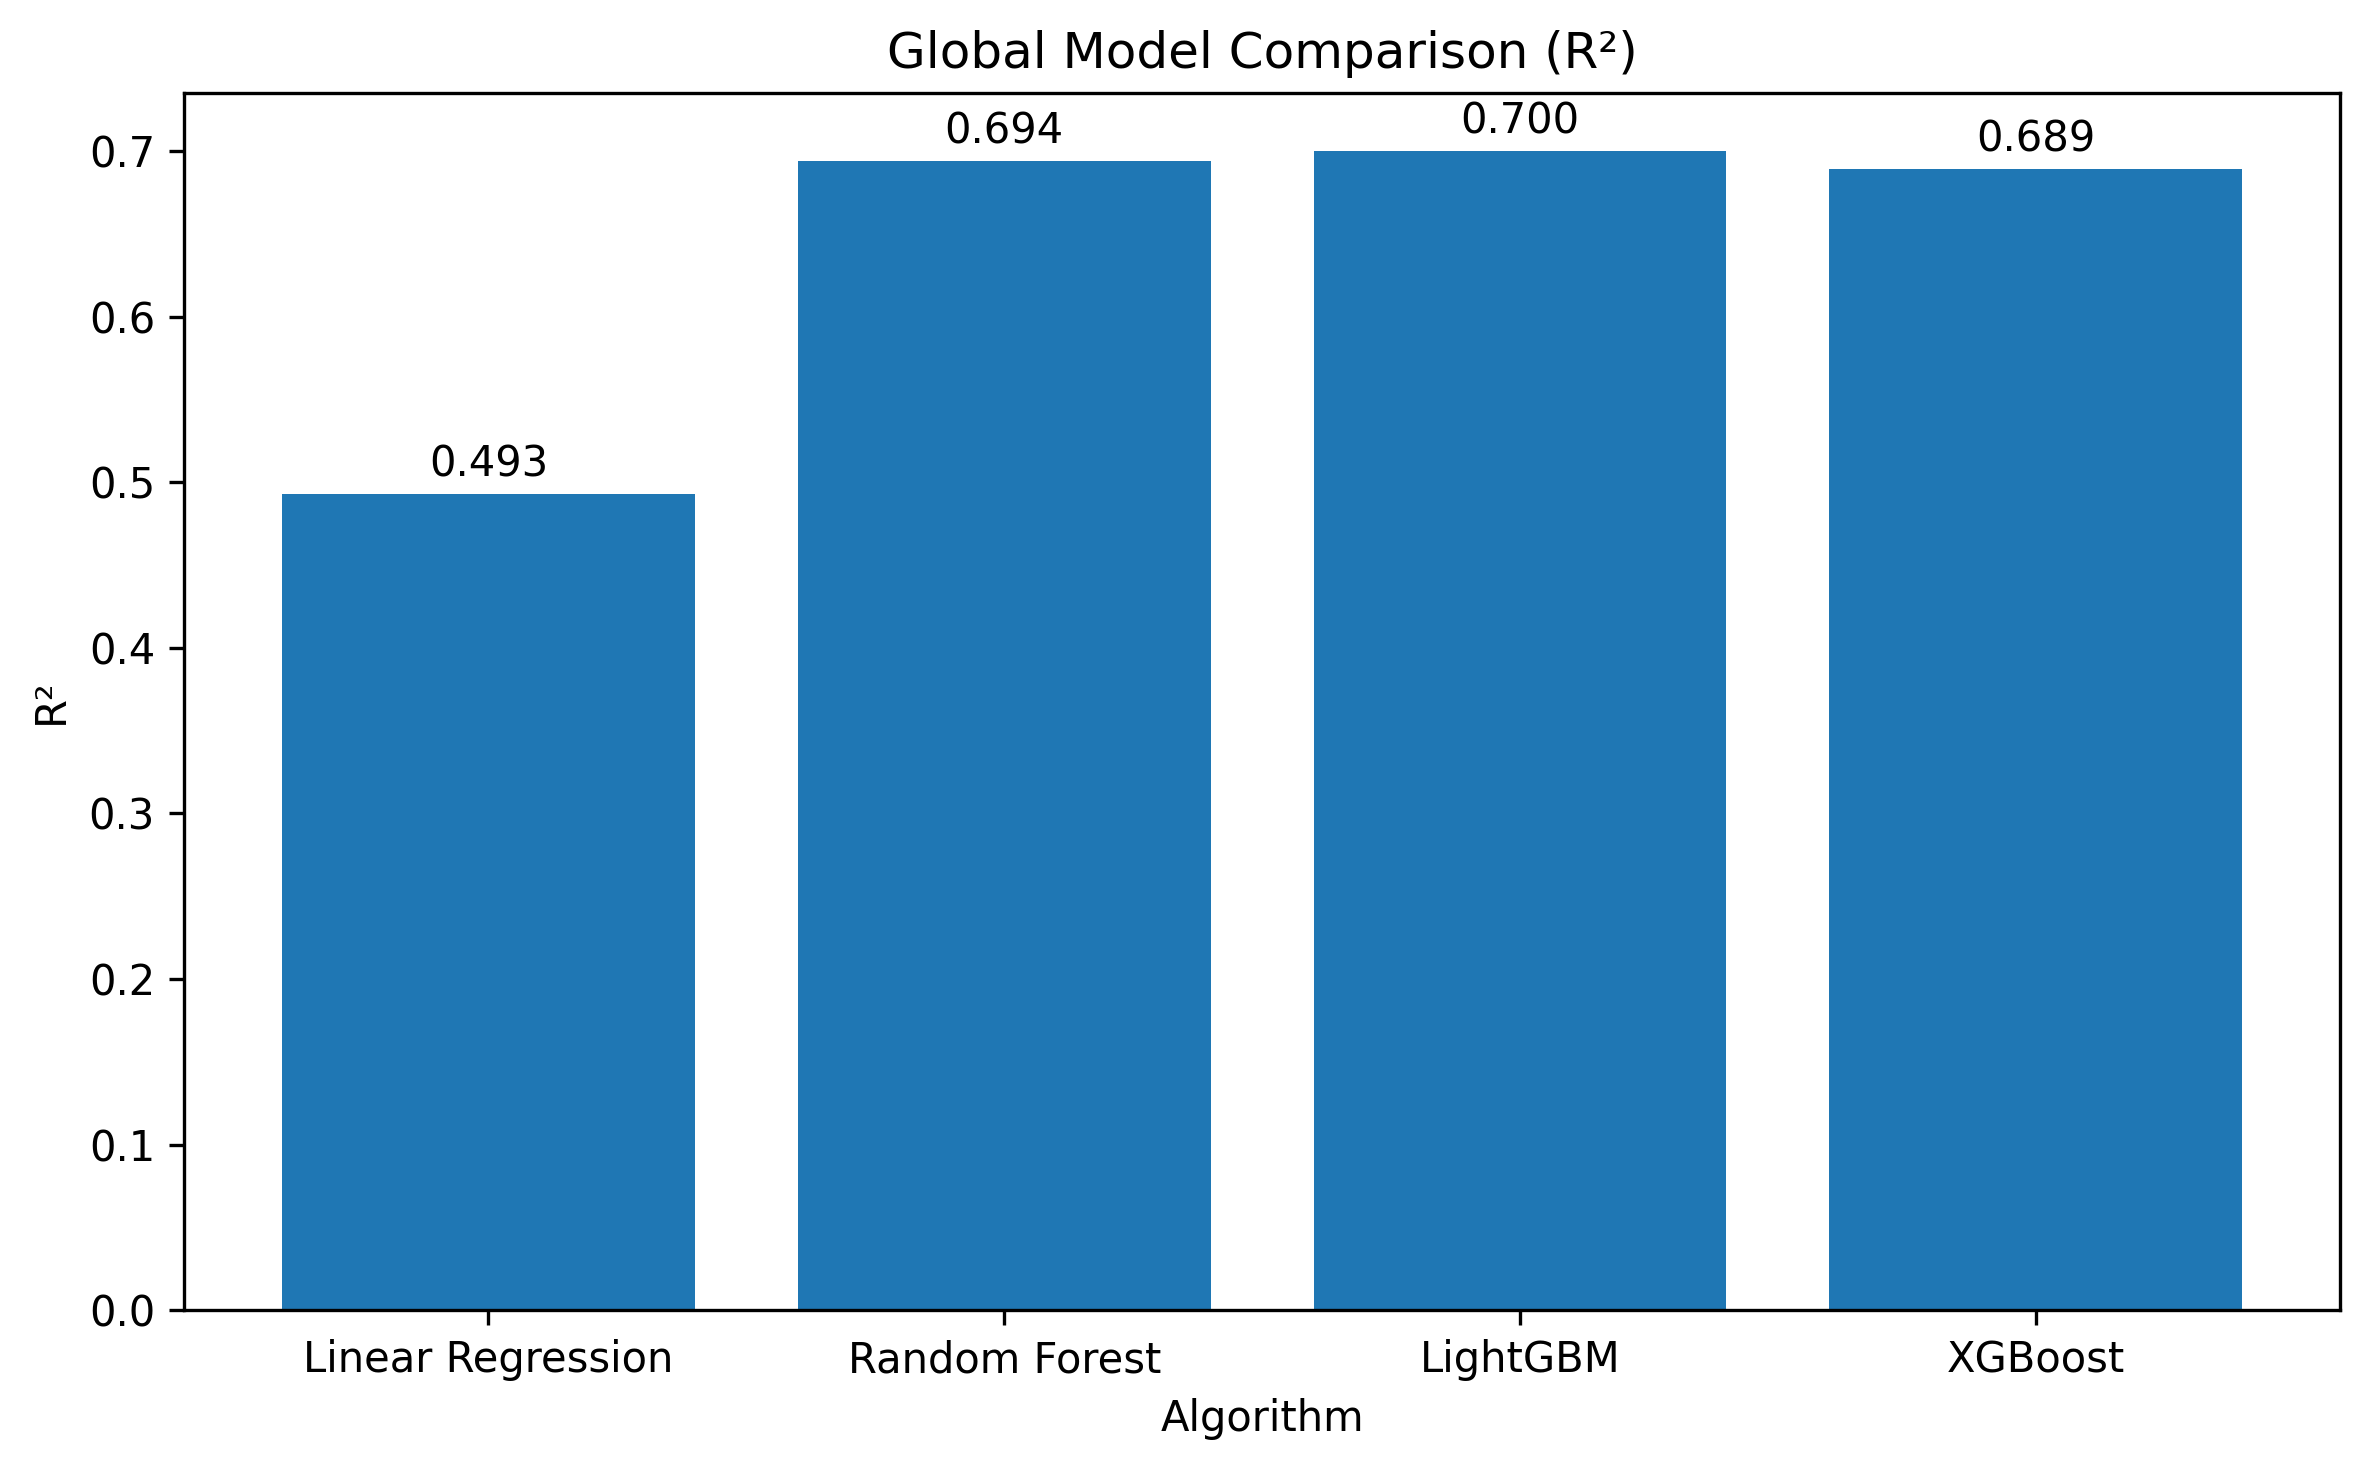

In [35]:
global_results = results_table[
    results_table["Dataset"] == "Global"
]

plt.figure(figsize=(8,5), dpi=300)

bars = plt.bar(
    global_results["Algorithm"],
    global_results["R2"]
)

plt.title("Global Model Comparison (R²)")
plt.xlabel("Algorithm")
plt.ylabel("R²")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.005,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom"
    )

plt.savefig(
    "/Users/kachi/Documents/Thesis/figures/global_r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

# Global comparison (MAE)

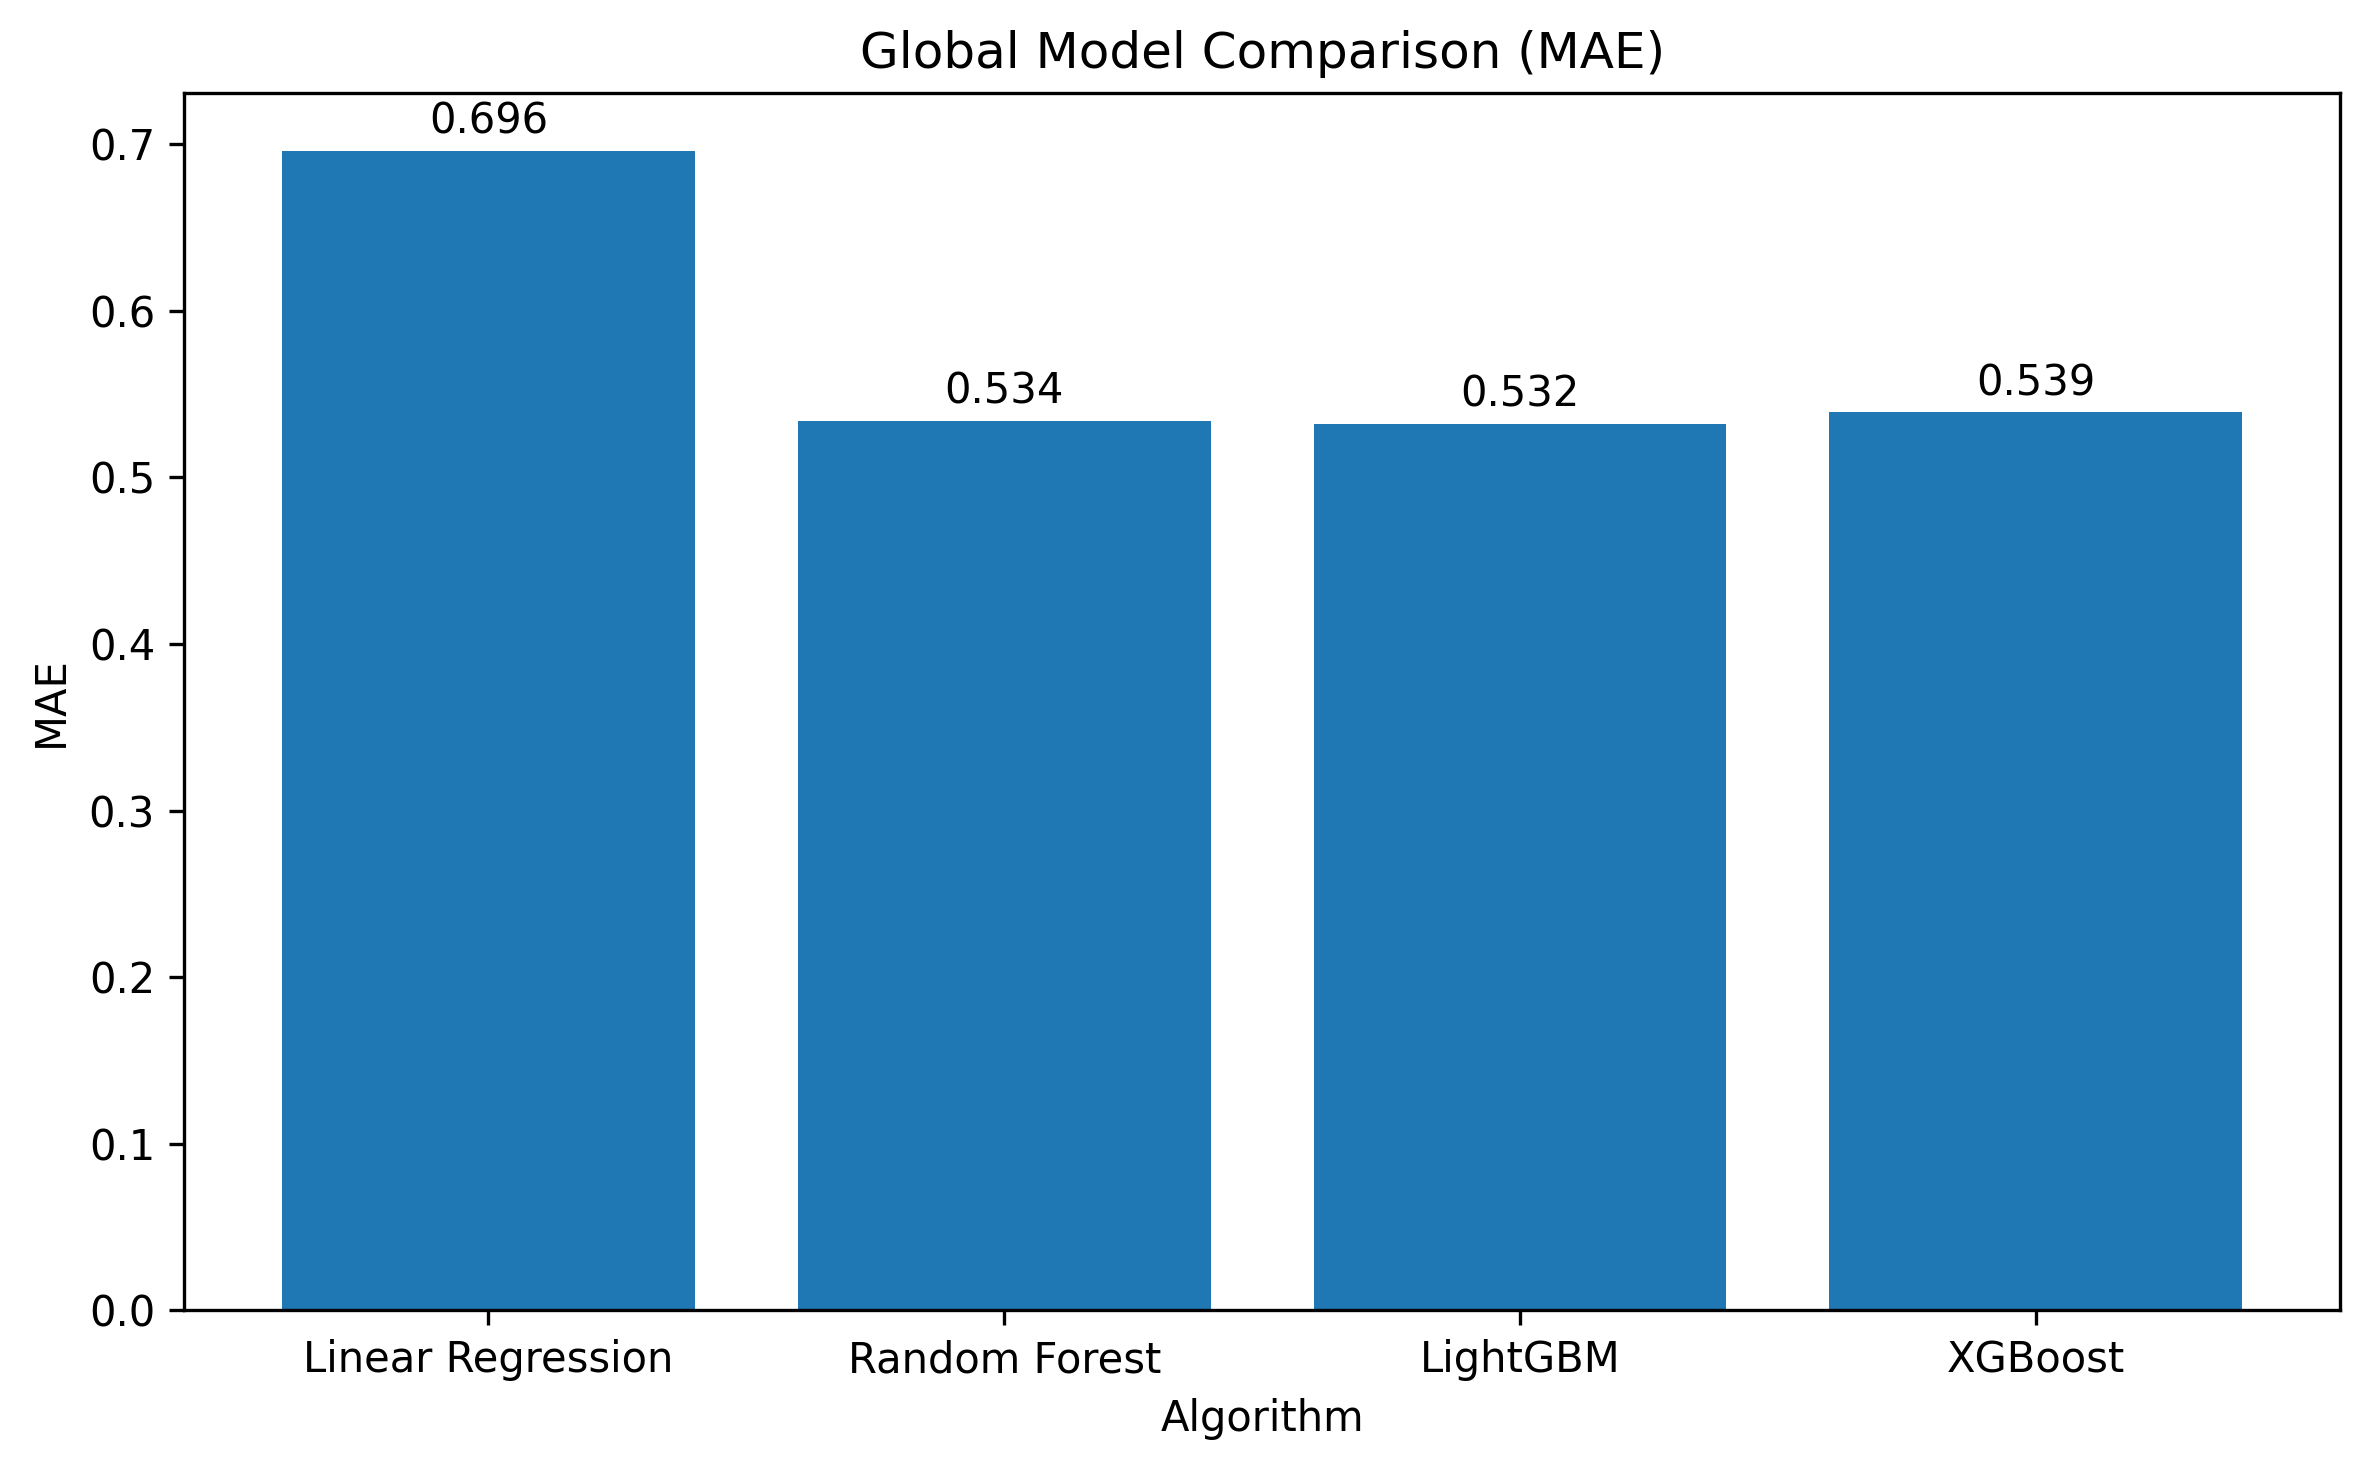

In [36]:
plt.figure(figsize=(8,5), dpi=300)

bars = plt.bar(
    global_results["Algorithm"],
    global_results["MAE"]
)

plt.title("Global Model Comparison (MAE)")
plt.xlabel("Algorithm")
plt.ylabel("MAE")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.005,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom"
    )
plt.savefig(
    "/Users/kachi/Documents/Thesis/figures/global_mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()



# Global comparison (RMSE)

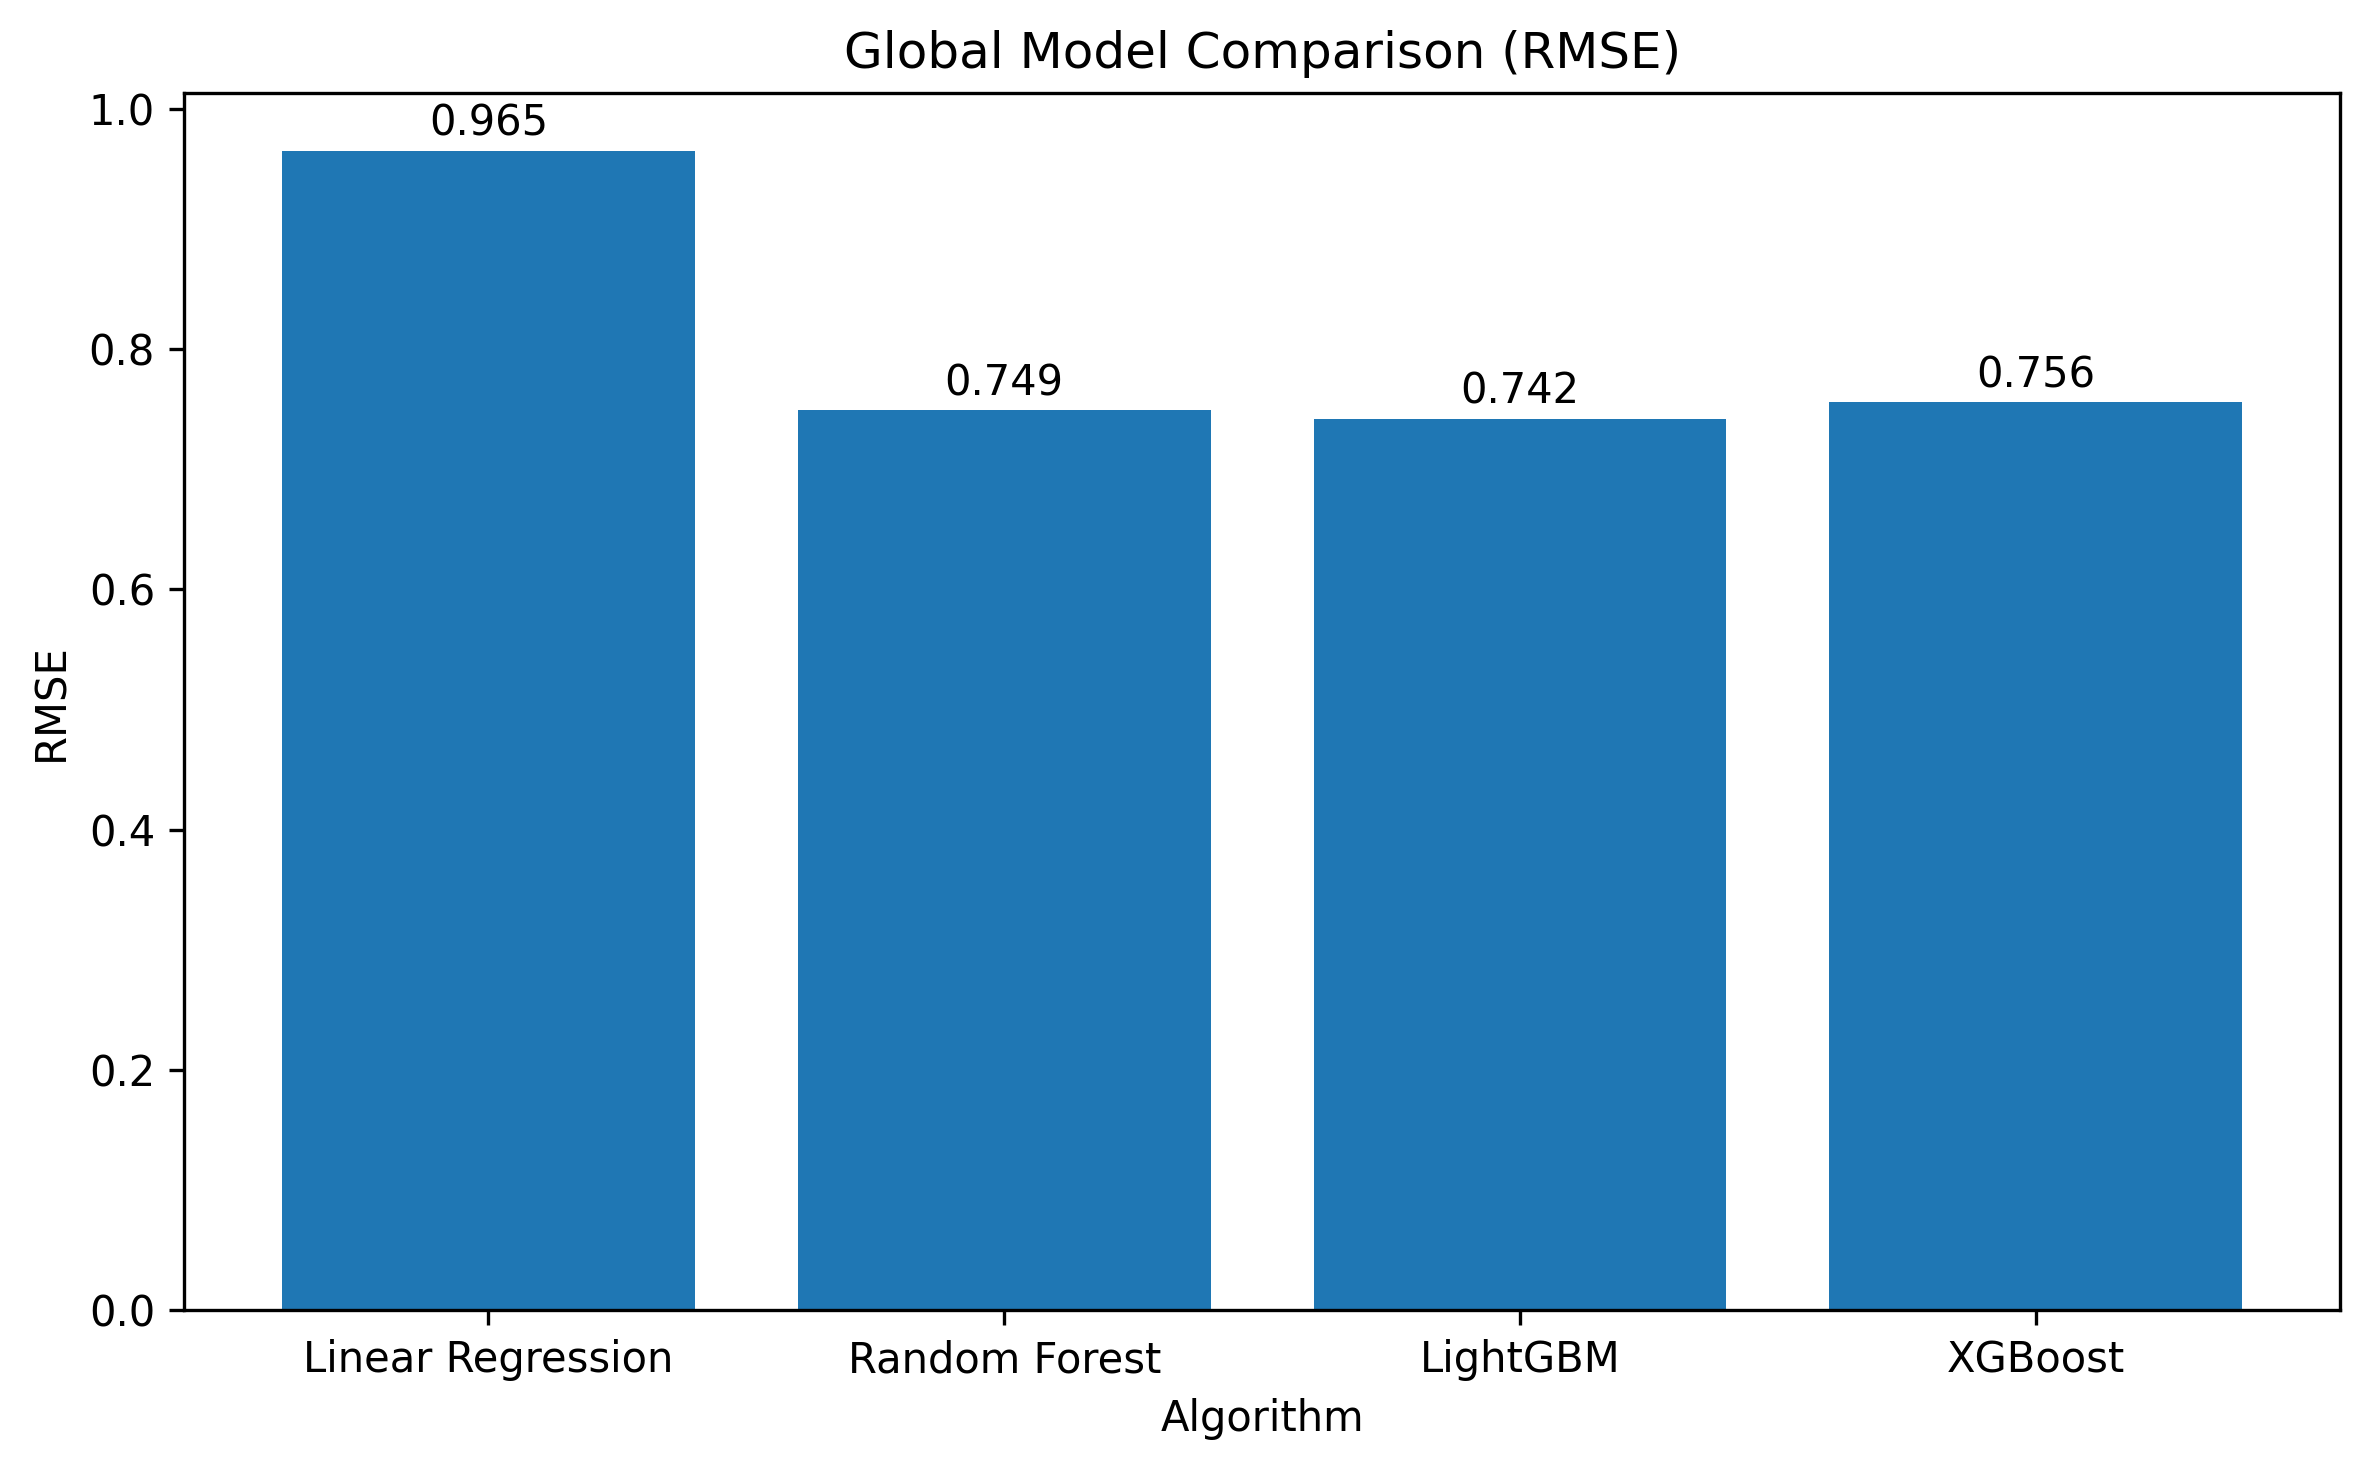

In [37]:
plt.figure(figsize=(8,5), dpi=300)

bars = plt.bar(
    global_results["Algorithm"],
    global_results["RMSE"]
)

plt.title("Global Model Comparison (RMSE)")
plt.xlabel("Algorithm")
plt.ylabel("RMSE")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.005,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom"
    )
    
plt.savefig(
    "/Users/kachi/Documents/Thesis/figures/global_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

# Position-specific comparison (R²)

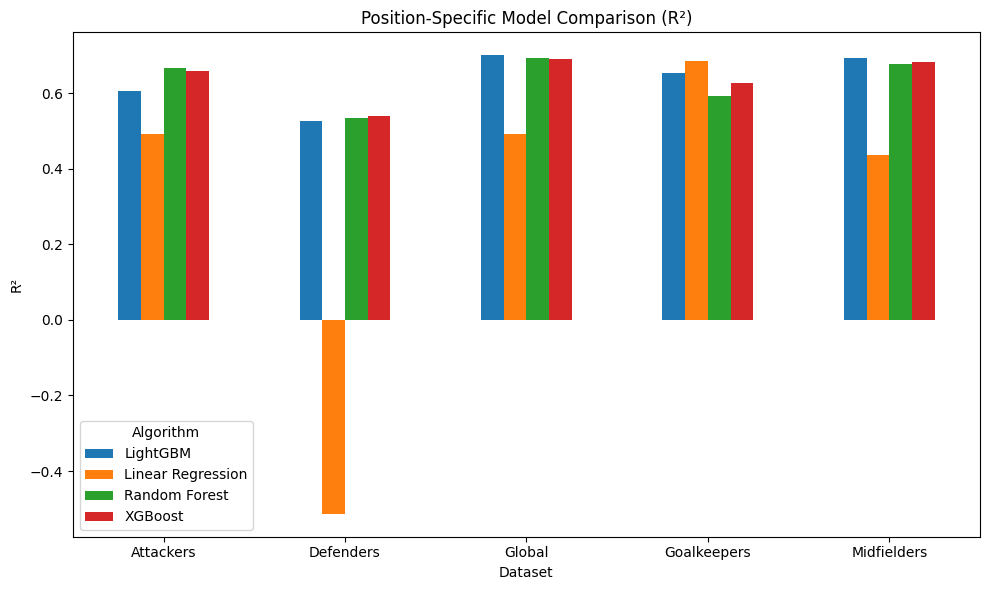

In [38]:
pivot_r2 = results_table.pivot(
    index="Dataset",
    columns="Algorithm",
    values="R2"
)

pivot_r2.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Position-Specific Model Comparison (R²)")
plt.xlabel("Dataset")
plt.ylabel("R²")

plt.xticks(rotation=0)

plt.savefig(
    "/Users/kachi/Documents/Thesis/figures/position_specific_r2_model.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [56]:
import os
os.getcwd()

'/Users/kachi/Documents/Thesis/notebooks'

In [57]:
os.listdir()

['03_exploratory_data_analysis.ipynb',
 'data_integration.ipynb',
 'arsenal_transfermarkt.csv',
 '.DS_Store',
 'downloaded_files',
 '02_transfermarkt_data_collection.ipynb',
 'transfermarkt_utils.py',
 '02_transfermarkt_data.ipynb',
 'arsenal_transfermarkt_clean.csv',
 'data_collection.ipynb',
 'fbref_standard_2425.csv',
 '__pycache__',
 '01_fbref_data_collection.ipynb',
 'transfer_test.ipynb',
 'transfermarkt_utils.ipynb',
 '02_fbref_feature_merge.ipynb',
 'transfermarkt_data.ipynb',
 '.ipynb_checkpoints',
 'fbref_clean.csv',
 '01_fbref_standard_2425.csv',
 '01_fbref_clean.csv',
 '04_model_development.ipynb',
 'arsenal_transfermarkt_raw.csv']